In [20]:
import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from scipy.ndimage import gaussian_filter1d
import matplotlib.cm as cm

# fig2b

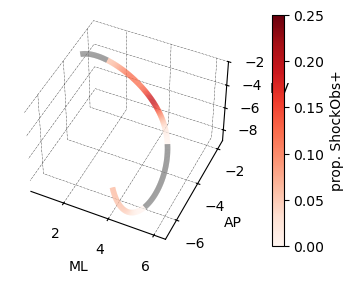

In [21]:
df_density = pd.read_parquet("SuppFig2b.parquet")
df_density["long_loc"] = pd.IntervalIndex.from_arrays(
    df_density["long_loc_left"],
    df_density["long_loc_right"],
    closed="right"
)

s = np.array( df_density.iloc[0].s )
curve = np.vstack( np.array( df_density.iloc[0].curve ) )

sigma = 15

# ============================================================
# PARSE INTERVALS
# ============================================================
starts = df_density["long_loc"].apply(lambda x: x.left).to_numpy()
ends = df_density["long_loc"].apply(lambda x: x.right).to_numpy()
densities = df_density["density"].to_numpy()

# ============================================================
# MAP DENSITY -> CURVE POINTS
# ============================================================
density_on_curve = np.full(len(s), np.nan)
for start, end, rho in zip(starts, ends, densities):
    mask = (s > start) & (s <= end)
    # ignore invalid bins
    if rho >= 0:
        density_on_curve[mask] = rho

valid_mask = density_on_curve >= 0
density_interp = np.interp(
    s,
    s[valid_mask],
    density_on_curve[valid_mask]
)
density_smooth = gaussian_filter1d(density_interp, sigma=sigma)
# restore invalid regions
density_smooth[~valid_mask] = np.nan
density_on_curve = density_smooth

# ============================================================
# CHOOSE COLORS
# ============================================================
cmap_name = "Reds"
# copy colormap so we can modify it
cmap = plt.get_cmap(cmap_name).copy()
cmap.set_bad(color="gray")

# ============================================================
# BUILD SEGMENT VALUES
# ============================================================
segment_density = 0.5 * (
    density_on_curve[:-1] +
    density_on_curve[1:]
)

# mask invalid values
segment_density_masked = np.ma.masked_where(
    segment_density < 0,
    segment_density
)

# normalization ONLY over valid values
valid_vals = segment_density[segment_density >= 0]

norm = Normalize(
    vmin=valid_vals.min(),
    vmax=valid_vals.max()
)

# ============================================================
# BUILD LINE SEGMENTS
# ============================================================
points = curve.reshape(-1, 1, 3)

segments = np.concatenate(
    [points[:-1], points[1:]],
    axis=1
)

# ============================================================
# PLOT
# ============================================================
fig = plt.figure(figsize=(4, 3))

# transparent figure background
fig.patch.set_alpha(0.0)

ax = fig.add_subplot(111, projection='3d')
# transparent axis pane backgrounds
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# optional: remove pane edges
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')

lc = Line3DCollection(
    segments,
    cmap=cmap,
    norm=norm,
    linewidth=4
)

lc.set_array(segment_density_masked)
lc.set_clim(0.0, 0.25)
ax.add_collection3d(lc)

# axis limits
ax.set_xlim(
    # curve[:,0].min(), curve[:,0].max()
    0.5, 6.5
)
ax.set_ylim(
    # curve[:,1].min(), curve[:,1].max()
    -7, -1.5
)
ax.set_zlim(
    # curve[:,2].min(), curve[:,2].max()
    -9, -2
)

# labels
ax.set_xlabel("ML")
ax.set_ylabel("AP")
ax.set_zlabel("DV")

# ---------------------------------------------------
# GRID CUSTOMIZATION
# ---------------------------------------------------
# turn grid on
ax.grid(True)

# customize grid appearance
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['linewidth'] = 0.25   # thickness
    axis._axinfo["grid"]['linestyle'] = '-.'  # '-', '--', ':', '-.'
    axis._axinfo["grid"]['color'] = 'black'# (0.2, 0.2, 0.2, 0.2)

# ---------------------------------------------------

# colorbar
cbar = fig.colorbar(lc, ax=ax, pad=0.1)
cbar.set_label("prop. ShockObs+")


ax.view_init(
    elev=45,   # vertical angle
    azim=-65    # horizontal rotation
)

plt.show()

# fig2c

/tmp/ipykernel_3926834/4261193665.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set( xlim=(0, 1), ylim=(0,100),


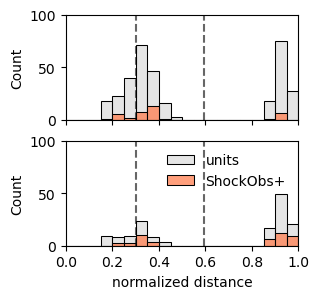

In [24]:
df = pd.read_parquet("SuppFig2c.parquet")

dorsal2intermediate = 3.8542964
intermediate2ventral = 7.62283897
dorsal2intermediate_norm = 0.29958059
intermediate2ventral_norm =0.59249585

#################
fig, ax = plt.subplots(2,1, figsize=(3,3), sharex=True, sharey=True)
bins = np.linspace(0, 1, 21)

sns.histplot( df.query("neuron_type=='pyr'")['long_loc_norm'],
              bins=bins, color='grey', alpha=0.2,
           ax=ax[0])
sns.histplot( df.query("neuron_type=='pyr' & shock_response=='excited'")['long_loc_norm'],
              bins=bins, color='coral', label='ShockObs+',
           ax=ax[0])

ax[0].axvline( dorsal2intermediate_norm, color = 'black', alpha=0.6, ls='--' )
ax[0].axvline( intermediate2ventral_norm, color = 'black', alpha=0.6, ls='--' )
# ax[0].set( xlim=(0, 1), xlabel='normalized distance')

sns.histplot( df.query("neuron_type=='int'")['long_loc_norm'],
              bins=bins, color='grey', alpha=0.2, label='units',
           ax=ax[1])
sns.histplot( df.query("neuron_type=='int' & shock_response=='excited'")['long_loc_norm'],
              bins=bins, color='coral', label='ShockObs+',
           ax=ax[1])

plt.legend()
ax[1].axvline( dorsal2intermediate_norm, color = 'black', alpha=0.6, ls='--' )
ax[1].axvline( intermediate2ventral_norm, color = 'black', alpha=0.6, ls='--' )
ax[1].set( xlim=(0, 1), ylim=(0,100),
           xlabel='normalized distance',
           xticklabels=['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'])

handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(frameon=False)

